# Survival on the Titanic: A Data-Driven Exploration

The sinking of the Titanic in 1912 remains one of the msot well-known maritime disasters in history.
Beyond the tragedy itself, the passenger data provides a unique opportunity to explore how age, gender, class, and economic status influences survival outcomes.
This project uses the official Titanic dataset from the Pandas documentation to:


*   practice data cleaning and preprocessing
*   perform exploratory data analysis

*   answer meaningful questions using Pandas
*   communicate insights through visualizations and narrative


The goal is to demonstrate practical data-analysis skils while uncovering patterns that shaped survival during the disaster.

We begin by loading the dataset directly from its Github source and insepcting its structure:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/pandas-dev/pandas/main/doc/data/titanic.csv"
df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe(include = "all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


The Titanic dataset is relatively clean, but we still document preprocessing steps:


*   Checking for missing values
*   Handling missing ages


*   Ensuring correct data types
*   Creating useful derived columns


In [5]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [6]:
# Fill missing ages with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Drop rows missing 'embarked'
df = df.dropna(subset = ['Embarked'])

# Convert categorical columns
df['Sex'] = df['Sex'].astype('category')
df['Pclass'] = df['Pclass'].astype('category')
df['Embarked'] = df['Embarked'].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  889 non-null    int64   
 1   Survived     889 non-null    int64   
 2   Pclass       889 non-null    category
 3   Name         889 non-null    object  
 4   Sex          889 non-null    category
 5   Age          889 non-null    float64 
 6   SibSp        889 non-null    int64   
 7   Parch        889 non-null    int64   
 8   Ticket       889 non-null    object  
 9   Fare         889 non-null    float64 
 10  Cabin        202 non-null    object  
 11  Embarked     889 non-null    category
dtypes: category(3), float64(2), int64(4), object(3)
memory usage: 72.4+ KB


In [18]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [19]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0,12,18,40,60,80],
                        labels=['Child','Teen','Adult','Middle Age','Senior'])

In [20]:
df['IsChild'] = df['Age'] < 12

In [45]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = df['FamilySize'] == 1
df['FarePerPerson'] = df['Fare'] / df['FamilySize']
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)', expand=False)
df[['FamilySize','IsAlone','FarePerPerson','Title']].head()
df['Title'].value_counts()
df['FamilySize'].value_counts()


,count
FamilySize,
1,535
2,161
3,102
4,29
6,22
5,15
7,12
11,7
8,6


We explore distributions, relationships, and correlations to understand the dataset before answering specific questions. In doing this, we can truly understand the data in the dataset and ask meaningful questions associated with that data.

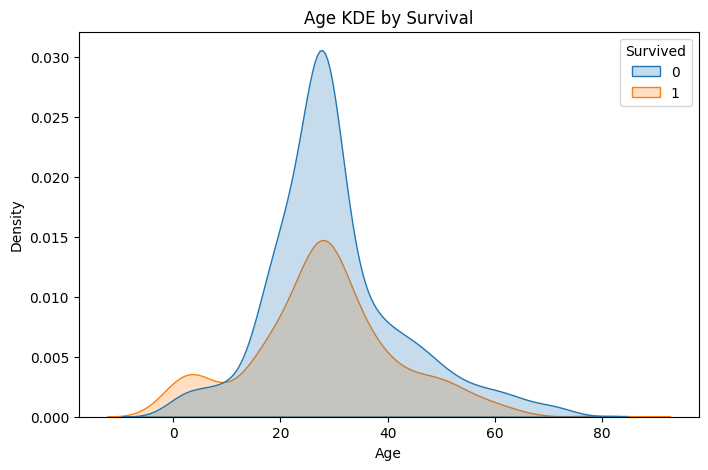

In [46]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='Age', hue='Survived', fill=True)
plt.title("Age KDE by Survival")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()

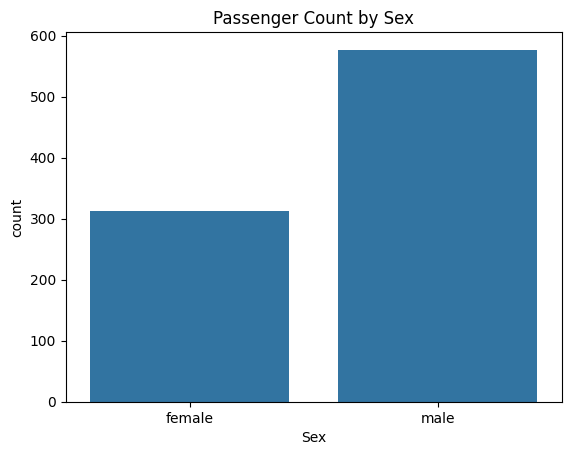

In [8]:
sns.countplot(data = df, x = 'Sex')
plt.title("Passenger Count by Sex")
plt.show()

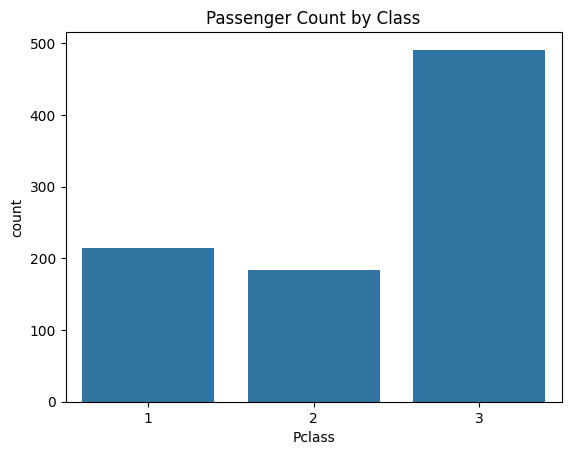

In [22]:
sns.countplot(data = df, x = 'Pclass')
plt.title("Passenger Count by Class")
plt.show()

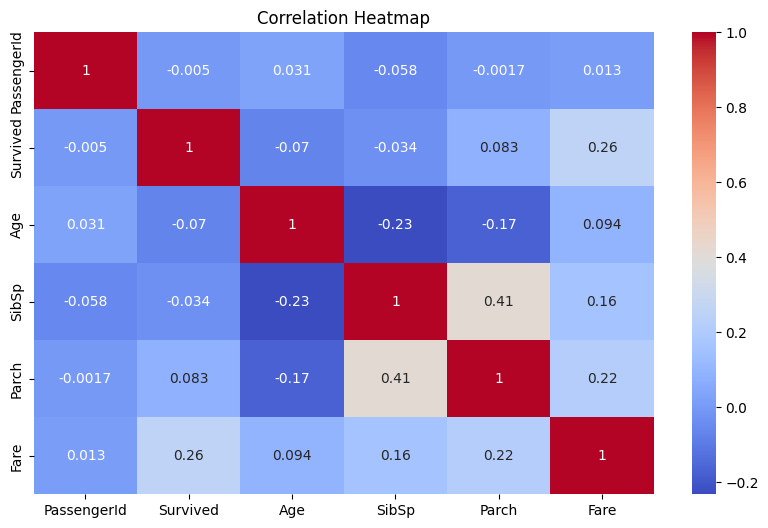

In [10]:
plt.figure(figsize = (10,6))
sns.heatmap(df.corr(numeric_only = True), annot = True, cmap = "coolwarm")
plt.title("Correlation Heatmap")
plt.show()

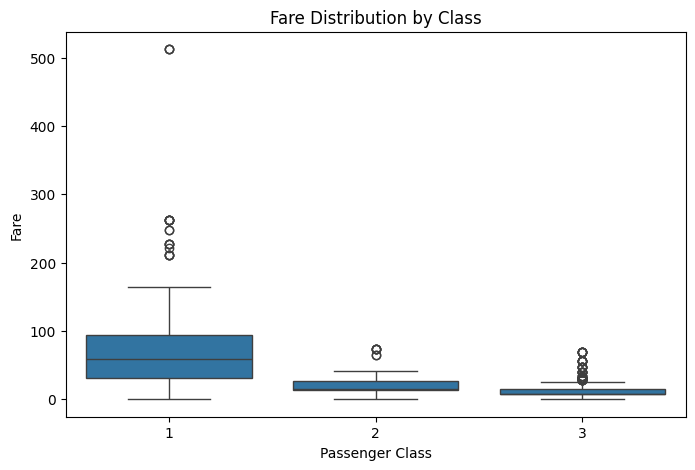

In [47]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Pclass', y='Fare')
plt.title("Fare Distribution by Class")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.show()

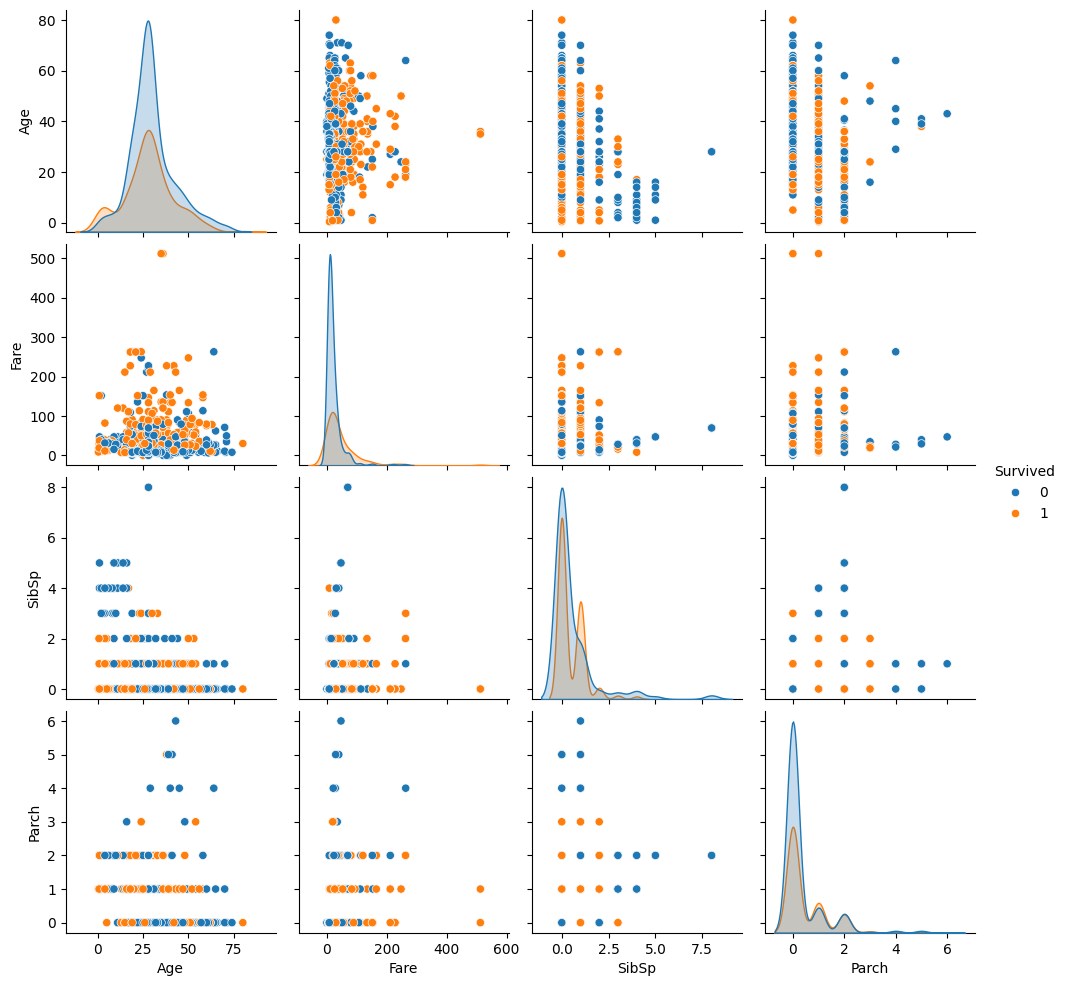

In [16]:
sns.pairplot(df[['Age','Fare','SibSp','Parch','Survived']], hue='Survived')

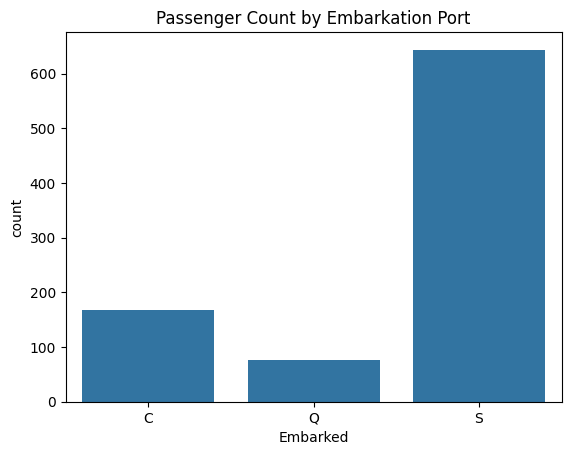

In [23]:
sns.countplot(data=df, x='Embarked')
plt.title("Passenger Count by Embarkation Port")
plt.show()

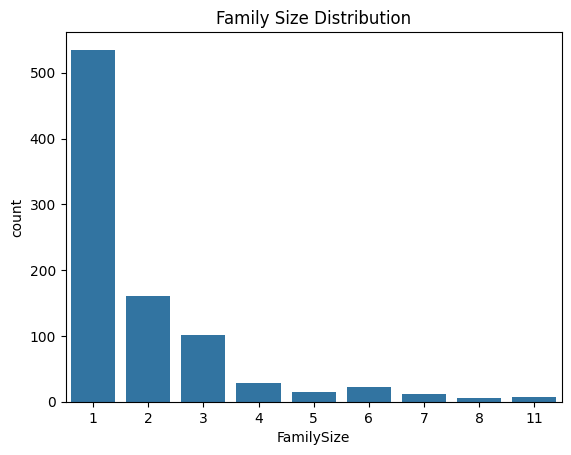

In [41]:
sns.countplot(data=df, x='FamilySize')
plt.title("Family Size Distribution")
plt.show()

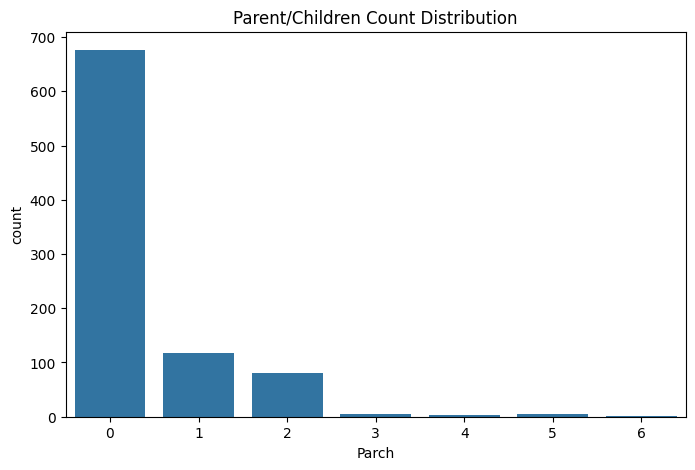

In [58]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Parch')
plt.title("Parent/Children Count Distribution")
plt.show()

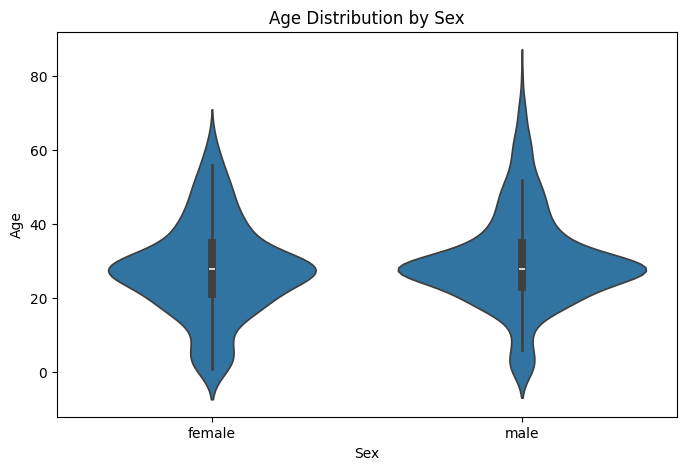

In [48]:
plt.figure(figsize=(8,5))
sns.violinplot(data=df, x='Sex', y='Age')
plt.title("Age Distribution by Sex")
plt.xlabel("Sex")
plt.ylabel("Age")
plt.show()

In [51]:
pd.crosstab(df['Sex'], df['Pclass'], normalize='index')

Pclass,1,2,3
Sex,,,
female,0.294872,0.243590,0.461538
male,0.211438,0.187175,0.601386


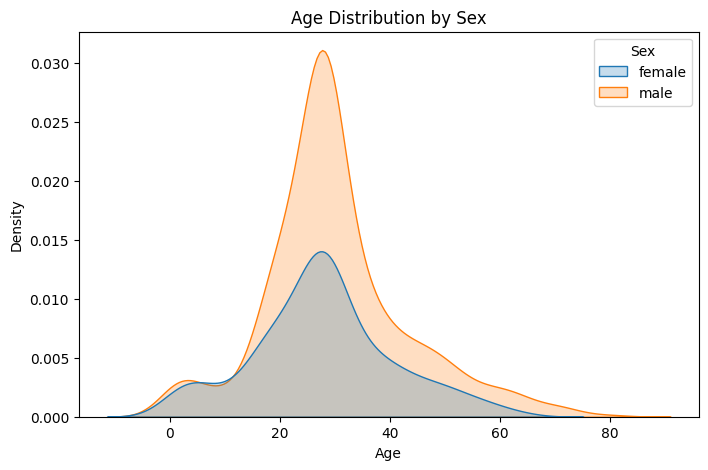

In [54]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='Age', hue='Sex', fill=True)
plt.title("Age Distribution by Sex")
plt.show()

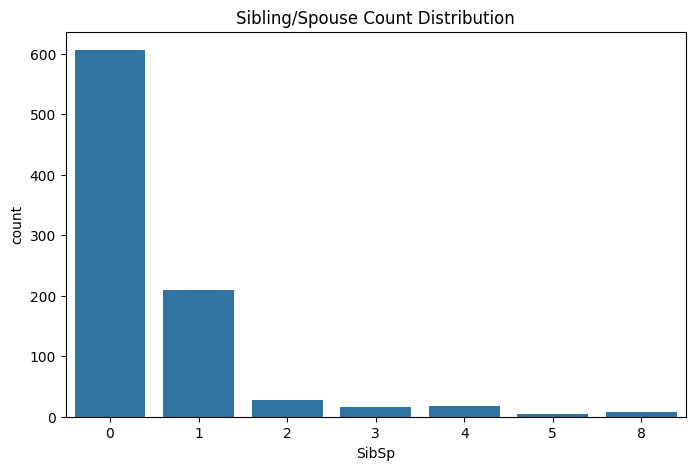

In [57]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='SibSp')
plt.title("Sibling/Spouse Count Distribution")
plt.show()

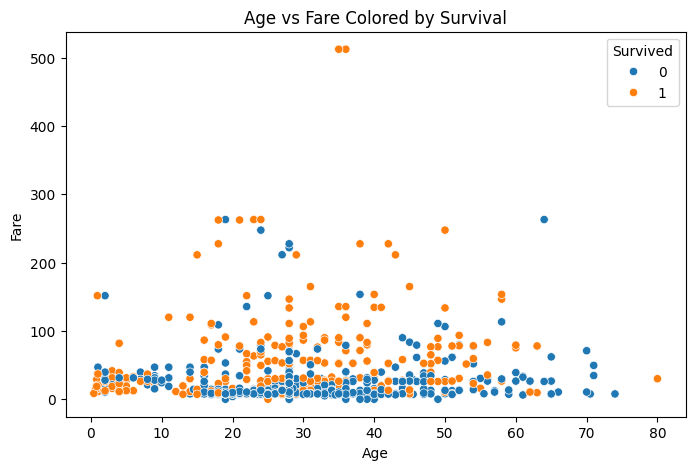

In [49]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Age', y='Fare', hue='Survived')
plt.title("Age vs Fare Colored by Survival")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

**Questions I Aim to Answer**
1. What is the overall survival rate?
2. Did women survive at higher rates than men?
3. How did passenger class affect survival?
4. Does age correlate with survival?
5. Which age groups were most vulnerable?
6. Did the port of embarkation influence survival?
7. How did fare differ between survivors and non-survivors?
8. What is the relatioship between family size and survival?
9. Did being alone increase the likelyhood of survival?
10. Were younger passengers mre likely to travel in higher classes?
11. What combination of factors best predicts survival patterns?
12. What were the differences in survival by Deck?

1. Overall Survival Rate

In [24]:
df['Survived'].mean()
df['Survived'].value_counts(normalize=True)

,proportion
Survived,
0,0.617548
1,0.382452


2. Survival Rate by Gender

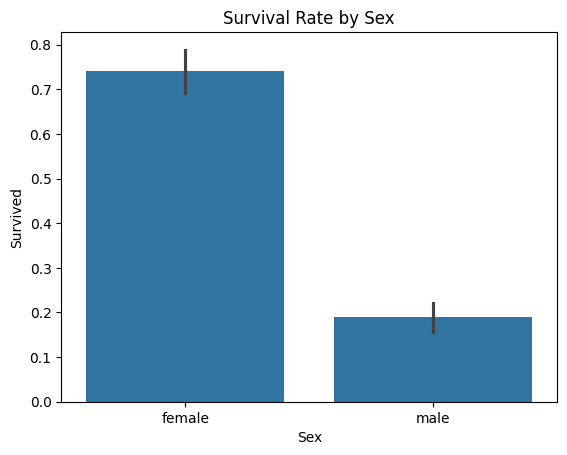

In [26]:
df.groupby('Sex', observed = True)['Survived'].mean()

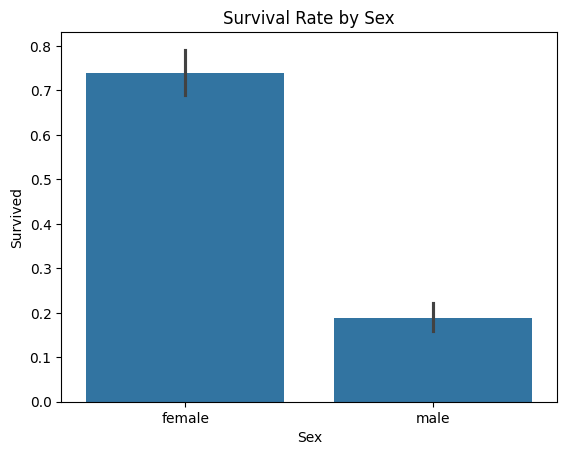

In [ ]:
sns.barplot(data = df, x = 'Sex', y = 'Survived')
plt.title("Survival Rate by Sex")
plt.show()

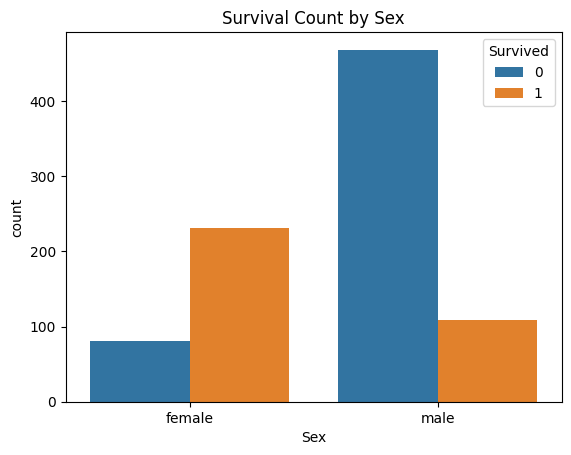

In [27]:
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title("Survival Count by Sex")
plt.show()

3. Survival Rate by Class

In [ ]:
df.groupby('Pclass', observed = True)['Survived'].mean()

,Survived
Pclass,
1,0.626168
2,0.472826
3,0.242363


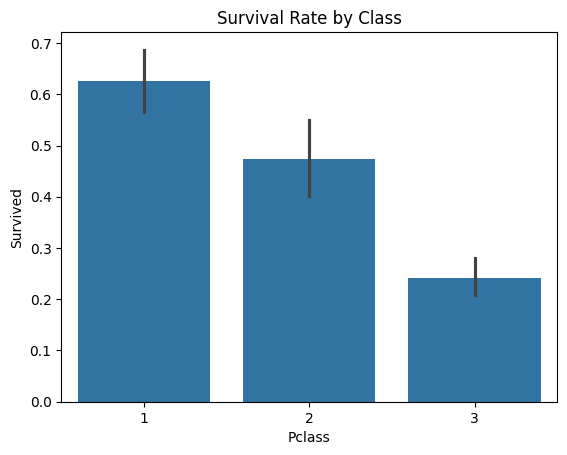

In [ ]:
sns.barplot(data = df, x = 'Pclass', y = 'Survived')
plt.title("Survival Rate by Class")
plt.show()

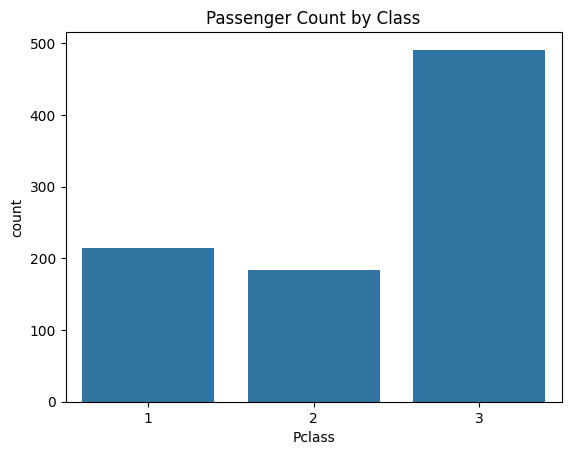

In [28]:
sns.countplot(data=df, x='Pclass')
plt.title("Passenger Count by Class")
plt.show()

4. Age vs Survival

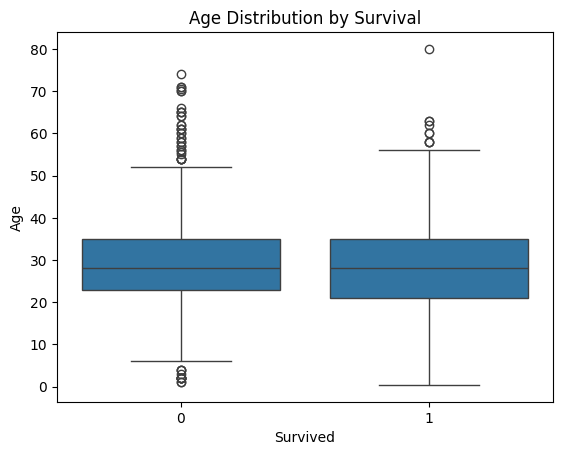

In [ ]:
sns.boxplot(data = df, x = 'Survived', y = 'Age')
plt.title("Age Distribution by Survival")
plt.show()

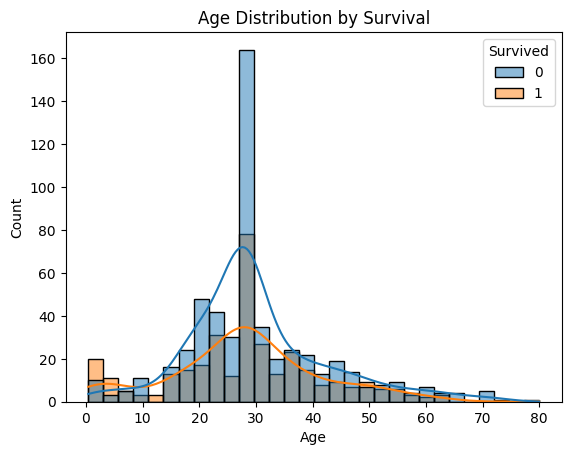

In [29]:
sns.histplot(data=df, x='Age', hue='Survived', kde=True)
plt.title("Age Distribution by Survival")
plt.show()

5. Age Groups

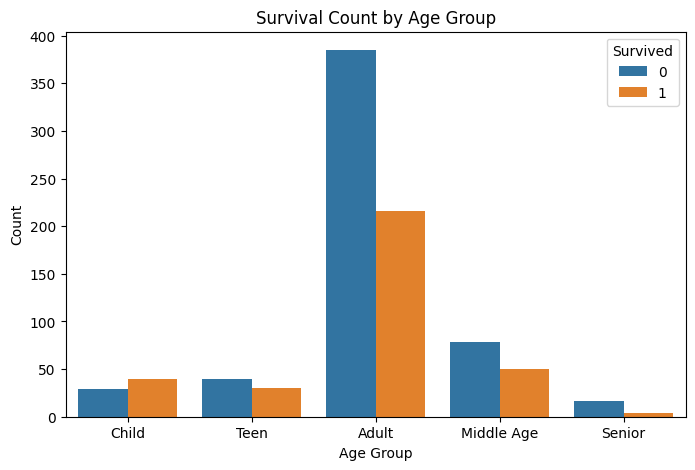

In [50]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='AgeGroup', hue='Survived')
plt.title("Survival Count by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

6. Embarkation Port

In [35]:
df.groupby('Embarked', observed = True)['Survived'].mean()

,Survived
Embarked,
C,0.553571
Q,0.389610
S,0.336957


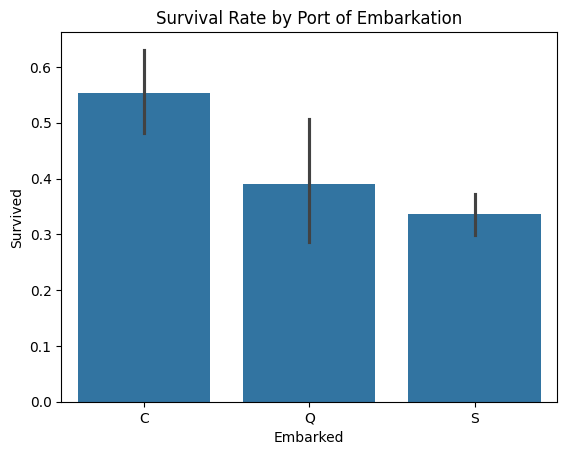

In [ ]:
sns.barplot(data=df, x='Embarked', y='Survived')
plt.title("Survival Rate by Port of Embarkation")
plt.show()

7. Fare Differences

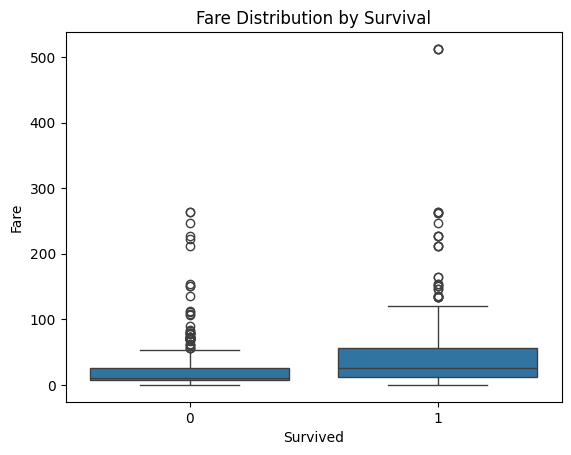

In [ ]:
sns.boxplot(data=df, x='Survived', y='Fare')
plt.title("Fare Distribution by Survival")
plt.show()

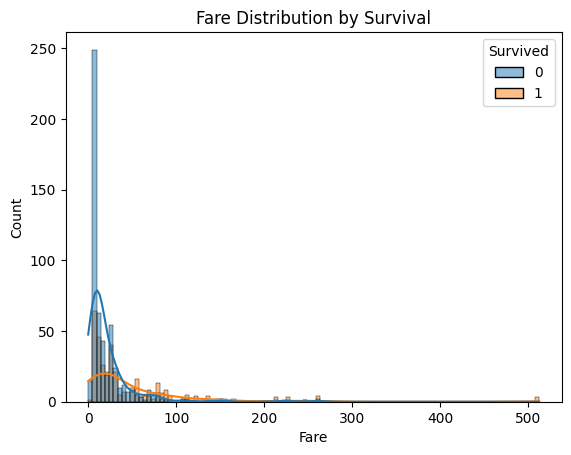

In [36]:
sns.histplot(data=df, x='Fare', hue='Survived', kde=True)
plt.title("Fare Distribution by Survival")
plt.show()

8. Family Size

In [ ]:
df['family_size'] = df['SibSp'] + df['Parch'] + 1

df.groupby('family_size')['Survived'].mean()

,Survived
family_size,
1,0.300935
2,0.552795
3,0.578431
4,0.724138
5,0.200000
6,0.136364
7,0.333333
8,0.000000
11,0.000000


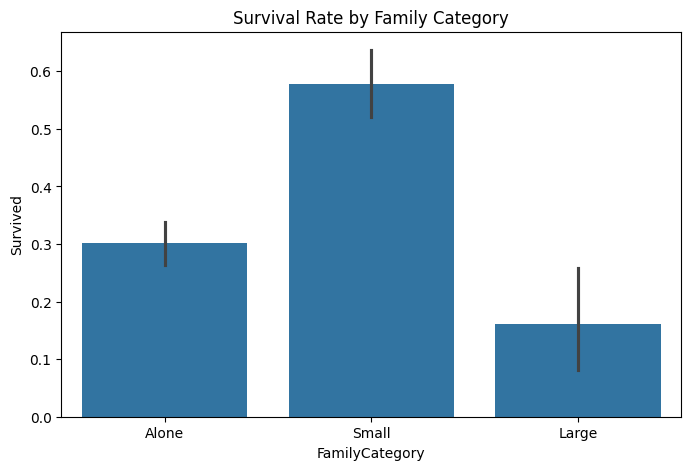

In [55]:
df['FamilyCategory'] = pd.cut(df['FamilySize'],
                              bins=[0,1,4,11],
                              labels=['Alone','Small','Large'])

plt.figure(figsize=(8,5))
sns.barplot(data=df, x='FamilyCategory', y='Survived')
plt.title("Survival Rate by Family Category")
plt.show()


9. Alone = Higher Survival Rate?

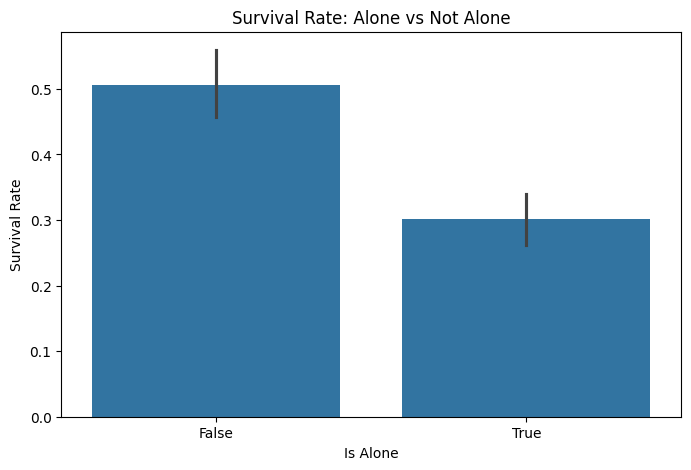

In [52]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='IsAlone', y='Survived')
plt.title("Survival Rate: Alone vs Not Alone")
plt.xlabel("Is Alone")
plt.ylabel("Survival Rate")
plt.show()

10. Age vs Class

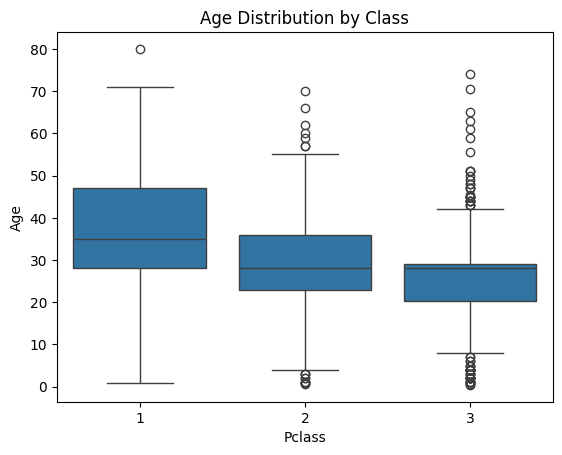

In [37]:
sns.boxplot(data=df, x='Pclass', y='Age')
plt.title("Age Distribution by Class")
plt.show()

11. Multivariate Insight

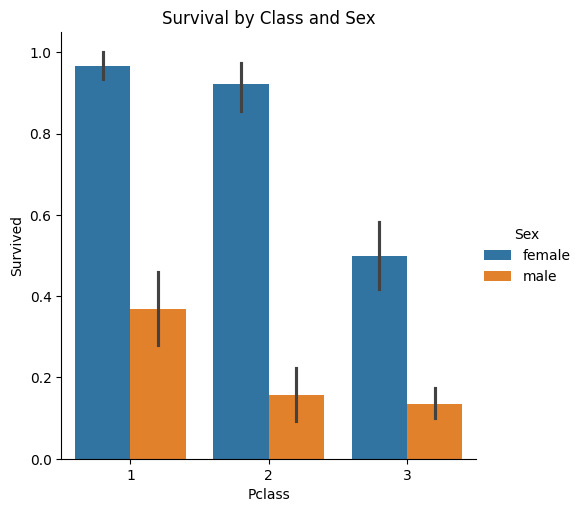

In [ ]:
sns.catplot(data=df, x='Pclass', y='Survived', hue='Sex', kind='bar')
plt.title("Survival by Class and Sex")
plt.show()

12. Survival by Deck

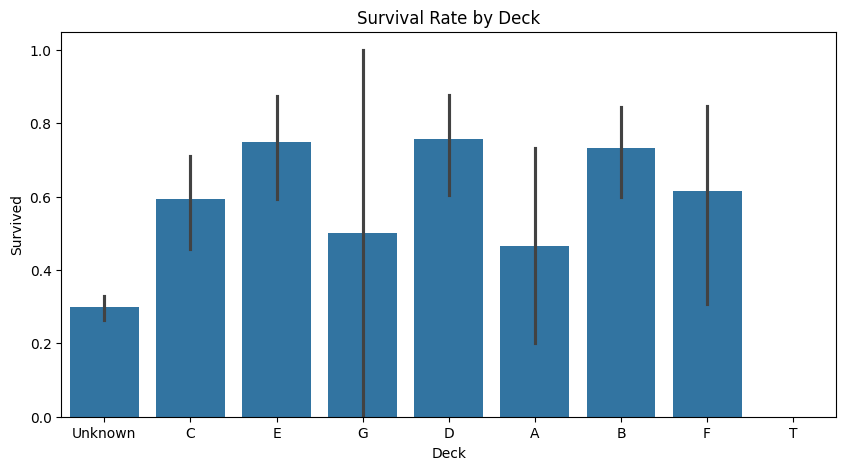

In [56]:
df['Deck'] = df['Cabin'].str[0].fillna('Unknown')

plt.figure(figsize=(10,5))
sns.barplot(data=df, x='Deck', y='Survived')
plt.title("Survival Rate by Deck")
plt.show()

# Final Insights


*   Women had significantly higher survival rates than men.
*   First-class passengers survived at much higher rates than lower classes.
*   Children had better survival outcomes than adults and seniors.
*   Higher fares correlated with higher survival, reflecting socioeconomic privilege
*   Passengers embarking from Cherbourg had the highest survival rates.
*   Family size showed a non-linear pattern: traveling alone or in very large groups reduced survival chances.


*   There was not a strong correlation between survival rate and the Deck that a passenger was staying on.



These findings highlight how gender, class, and economic status shaped survival during the Titanic disaster - revealing structural inequalities even in moments of crisis.





